In [112]:
"""
====================================================================
Google Earth Engine - Runoff Prediction Framework
สำหรับการพยากรณ์สมดุลน้ำในลุ่มน้ำน่าน
====================================================================
"""

import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json

# Deep Learning
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap

# Initialize GEE
try:
    ee.Initialize(project="ee-sakda-451407")
except Exception as e:
    ee.Authenticate() # หากยังไม่ได้ยืนยันตัวตน ให้ทำการยืนยัน
    ee.Initialize(project="ee-sakda-451407")  

# ====================================================================
# 1. CONFIGURATION & STUDY AREA
# ====================================================================

class Config:
    """Configuration for Nan River Basin Study"""
    
    # Study Area (ลุ่มน้ำน่าน - ปรับ coordinates ตามพื้นที่จริง)
    # BASIN_BOUNDARY = ee.Geometry.Polygon([
    #     [[100.0, 17.5], [101.5, 17.5], 
    #      [101.5, 19.5], [100.0, 19.5], [100.0, 17.5]]
    # ])
    # use this asset: https://code.earthengine.google.com/?asset=projects/sakdagee/assets/basin_n1_4326
    BASIN_BOUNDARY = ee.FeatureCollection("projects/sakdagee/assets/basin_n1_4326")
    
    # Time Period
    START_DATE = '2014-01-01'
    END_DATE = '2024-12-31'
    
    # Datasets
    CHIRPS = 'UCSB-CHG/CHIRPS/DAILY'
    GPM = 'NASA/GPM_L3/IMERG_V06'
    MOD16 = 'MODIS/006/MOD16A2'
    SSEBOP = 'projects/usgs-ssebop/system:et_fraction'
    MOD11 = 'MODIS/006/MOD11A2'
    MODIS_NDVI = 'MODIS/006/MOD13A2'
    SMAP = 'NASA_USDA/HSL/SMAP10KM_soil_moisture'
    LANDCOVER = 'MODIS/006/MCD12Q1'
    
    # Spatial Resolution
    SCALE = 1000  # meters
    
    # Model Parameters
    LSTM_LOOKBACK = 30  # จำนวนวันย้อนหลังสำหรับ LSTM
    TRAIN_RATIO = 0.8


In [113]:
# show study area on folium map

import folium

study_area = ee.FeatureCollection("projects/sakdagee/assets/basin_n1_4326")

# config figure height
f = folium.Figure(height=300)

# add map to figure
m = folium.Map(location=[18.9, 99.0], zoom_start=7).add_to(f)

# add study area to map
folium.GeoJson(study_area.getInfo()).add_to(m)

m

In [114]:
# ====================================================================
# 2. DATA EXTRACTION FROM GEE
# ====================================================================

class GEEDataExtractor:
    """Extract hydrological data from Google Earth Engine"""
    
    def __init__(self, geometry, start_date, end_date):
        self.geometry = geometry
        self.start_date = start_date
        self.end_date = end_date
        self.scale = Config.SCALE
        
    def extract_precipitation(self, source='CHIRPS'):
        """Extract precipitation data"""
        print("Extracting Precipitation...")
        
        if source == 'CHIRPS':
            dataset = ee.ImageCollection(Config.CHIRPS) \
                .filterDate(self.start_date, self.end_date) \
                .filterBounds(self.geometry)
            band = 'precipitation'
        elif source == 'GPM':
            dataset = ee.ImageCollection(Config.GPM) \
                .filterDate(self.start_date, self.end_date) \
                .filterBounds(self.geometry) \
                .select('precipitationCal')
            band = 'precipitationCal'
        
        return self._reduce_region_timeseries(dataset, band, 'precipitation')
    
    def extract_evapotranspiration(self):
        """Extract ET data (MOD16)"""
        print("Extracting Evapotranspiration...")
        
        dataset = ee.ImageCollection(Config.MOD16) \
            .filterDate(self.start_date, self.end_date) \
            .filterBounds(self.geometry) \
            .select('ET')
        
        # Convert to mm/day and preserve date
        dataset = dataset.map(lambda img: img.multiply(0.1).copyProperties(img, ['system:time_start']))
        
        return self._reduce_region_timeseries(dataset, 'ET', 'et')
    
    def extract_ndvi(self):
        """Extract NDVI (MODIS)"""
        print("Extracting NDVI...")
        
        dataset = ee.ImageCollection(Config.MODIS_NDVI) \
            .filterDate(self.start_date, self.end_date) \
            .filterBounds(self.geometry) \
            .select('NDVI')
        
        # Scale NDVI and preserve date
        dataset = dataset.map(lambda img: img.multiply(0.0001).copyProperties(img, ['system:time_start']))
        
        return self._reduce_region_timeseries(dataset, 'NDVI', 'ndvi')
    
    def extract_lst(self):
        """Extract Land Surface Temperature"""
        print("Extracting LST...")
        
        dataset = ee.ImageCollection(Config.MOD11) \
            .filterDate(self.start_date, self.end_date) \
            .filterBounds(self.geometry) \
            .select('LST_Day_1km')
        
        # Convert to Celsius and preserve date
        dataset = dataset.map(lambda img: img.multiply(0.02).subtract(273.15).copyProperties(img, ['system:time_start']))
        
        return self._reduce_region_timeseries(dataset, 'LST_Day_1km', 'lst')
    
    def extract_soil_moisture(self):
        """Extract Soil Moisture (SMAP)"""
        print("Extracting Soil Moisture...")
        
        dataset = ee.ImageCollection(Config.SMAP) \
            .filterDate(self.start_date, self.end_date) \
            .filterBounds(self.geometry) \
            .select('ssm')
        
        return self._reduce_region_timeseries(dataset, 'ssm', 'soil_moisture')
    
    def extract_land_cover(self, year=2020):
        """Extract dominant land cover type"""
        print("Extracting Land Cover...")
        
        lc = ee.ImageCollection(Config.LANDCOVER) \
            .filterDate(f'{year}-01-01', f'{year}-12-31') \
            .first() \
            .select('LC_Type1')
        
        # Get mode (most common) land cover type
        mode_lc = lc.reduceRegion(
            reducer=ee.Reducer.mode(),
            geometry=self.geometry,
            scale=self.scale,
            maxPixels=1e9
        )
        
        return mode_lc.getInfo()
    
    def _reduce_region_timeseries(self, collection, band, output_name):
        """Helper function to reduce time series to basin mean"""
        
        def reduce_image(img):
            stat = img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=self.geometry,
                scale=self.scale,
                maxPixels=1e9
            )
            return ee.Feature(None, {
                'date': img.date().format('YYYY-MM-dd'),
                output_name: stat.get(band)
            })
        
        features = collection.map(reduce_image)
        
        # Export to dictionary
        data = features.getInfo()
        
        # Convert to pandas DataFrame
        df = pd.DataFrame([f['properties'] for f in data['features']])
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date').sort_index()
        
        return df

In [115]:
# ====================================================================
# 3. DATA PREPROCESSING
# ====================================================================

class DataPreprocessor:
    """Preprocess and prepare data for modeling"""
    
    @staticmethod
    def merge_datasets(data_dict):
        """Merge all datasets into single DataFrame"""
        print("Merging datasets...")
        
        df_merged = pd.DataFrame()
        for name, df in data_dict.items():
            if df_merged.empty:
                df_merged = df
            else:
                df_merged = df_merged.join(df, how='outer')
        
        return df_merged
    
    @staticmethod
    def fill_missing_values(df, method='interpolate'):
        """Fill missing values"""
        print("Filling missing values...")
        
        if method == 'interpolate':
            df = df.interpolate(method='time', limit_direction='both')
        elif method == 'forward':
            df = df.fillna(method='ffill').fillna(method='bfill')
        
        return df
    
    @staticmethod
    def add_temporal_features(df):
        """Add temporal features"""
        print("Adding temporal features...")
        
        df['month'] = df.index.month
        df['day_of_year'] = df.index.dayofyear
        df['season'] = df['month'].apply(
            lambda x: 1 if x in [3,4,5] else  # Spring
                     2 if x in [6,7,8] else  # Summer/Rainy
                     3 if x in [9,10,11] else  # Autumn
                     4  # Winter
        )
        
        return df
    
    @staticmethod
    def calculate_water_balance_features(df):
        """Calculate water balance related features"""
        print("Calculating water balance features...")
        
        if 'precipitation' in df.columns and 'et' in df.columns:
            df['precip_et_diff'] = df['precipitation'] - df['et']
            df['precip_7d_sum'] = df['precipitation'].rolling(7).sum()
            df['precip_30d_sum'] = df['precipitation'].rolling(30).sum()
            df['et_7d_mean'] = df['et'].rolling(7).mean()
        
        if 'soil_moisture' in df.columns:
            df['sm_change'] = df['soil_moisture'].diff()
        
        return df
    
    @staticmethod
    def add_lag_features(df, target_col='runoff', lags=[1, 2, 3, 7, 14]):
        """Add lag features for target variable"""
        print(f"Adding lag features for {target_col}...")
        
        if target_col in df.columns:
            for lag in lags:
                df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
        
        return df
    
    @staticmethod
    def remove_outliers(df, columns=None, n_std=3):
        """Remove outliers using z-score method"""
        print("Removing outliers...")
        
        if columns is None:
            columns = df.select_dtypes(include=[np.number]).columns
        
        df_clean = df.copy()
        for col in columns:
            if col in df.columns:
                mean = df[col].mean()
                std = df[col].std()
                df_clean = df_clean[(df[col] - mean).abs() <= n_std * std]
        
        print(f"Removed {len(df) - len(df_clean)} outlier rows")
        return df_clean
    
    @staticmethod
    def normalize_data(df, exclude_cols=['runoff'], scale_target=True):
        """Normalize features and optionally target using MinMaxScaler"""
        print("Normalizing data...")
        
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler() if scale_target else None
        
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        df_scaled = df.copy()
        df_scaled[feature_cols] = scaler_X.fit_transform(df[feature_cols])
        
        # Scale target variable if specified
        if scale_target and exclude_cols[0] in df.columns:
            df_scaled[exclude_cols[0]] = scaler_y.fit_transform(df[[exclude_cols[0]]])
        
        return df_scaled, scaler_X, scaler_y

In [116]:

# ====================================================================
# 4. FEATURE IMPORTANCE ANALYSIS
# ====================================================================

class FeatureImportance:
    """Analyze feature importance for runoff prediction"""
    
    @staticmethod
    def correlation_analysis(df, target='runoff'):
        """Correlation analysis"""
        print("Performing correlation analysis...")
        
        correlations = df.corr()[target].sort_values(ascending=False)
        
        # Visualization
        plt.figure(figsize=(10, 8))
        sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
        plt.title('Correlation Matrix')
        plt.tight_layout()
        plt.show()
        # plt.savefig('correlation_matrix.png', dpi=300)
        # plt.close()
        
        return correlations
    
    @staticmethod
    def random_forest_importance(X, y):
        """Random Forest feature importance"""
        print("Calculating Random Forest importance...")
        
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        
        importance_df = pd.DataFrame({
            'feature': X.columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Visualization
        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['feature'][:10], importance_df['importance'][:10])
        plt.xlabel('Importance')
        plt.title('Top 10 Feature Importance (Random Forest)')
        plt.tight_layout()
        plt.show()
        # plt.savefig('rf_importance.png', dpi=300)
        # plt.close()
        
        return importance_df, rf
    
    @staticmethod
    def shap_analysis(model, X, max_display=10):
        """SHAP values analysis"""
        print("Calculating SHAP values...")
        
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        
        # Summary plot
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X, max_display=max_display, show=False)
        plt.tight_layout()
        plt.show()
        # plt.savefig('shap_summary.png', dpi=300)
        # plt.close()
        
        return shap_values


In [117]:
# ====================================================================
# 5. SIMPLE NEURAL NETWORK FOR RUNOFF PREDICTION
# ====================================================================

class SimpleRunoffModel:
    """Simple feedforward neural network for runoff prediction"""
    
    def __init__(self):
        self.model = None
        self.history = None
        
    def build_model(self, input_dim):
        """Build simple feedforward neural network"""
        print(f"Building simple NN model with {input_dim} input features...")
        
        model = Sequential([
            Dense(32, activation='relu', input_dim=input_dim),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dropout(0.2),
            Dense(8, activation='relu'),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001), 
            loss='mse', 
            metrics=['mae']
        )
        self.model = model
        
        print(model.summary())
        return model
    
    def train(self, X_train, y_train, X_val, y_val, epochs=200, batch_size=32):
        """Train the model"""
        print("Training model...")
        
        print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
        print(f"Validation data shape: X={X_val.shape}, y={y_val.shape}")
        
        # Build model if not exists
        if self.model is None:
            self.build_model(X_train.shape[1])
        
        # Callbacks
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=40, restore_best_weights=True, verbose=1
        )
        
        reduce_lr = keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=20, min_lr=0.00001, verbose=1
        )
        
        # Train
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )
        
        return self.history
    
    def predict(self, X):
        """Make predictions"""
        return self.model.predict(X, verbose=0)
    
    def evaluate(self, X_test, y_test, scaler_y=None):
        """Evaluate model performance"""
        print("Evaluating model...")
        
        y_pred = self.predict(X_test)
        y_true = y_test
        
        # Inverse transform if scaler provided
        if scaler_y is not None:
            y_true_orig = scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
            y_pred_orig = scaler_y.inverse_transform(y_pred).flatten()
        else:
            y_true_orig = y_true.flatten()
            y_pred_orig = y_pred.flatten()
        
        # Metrics on original scale
        rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
        mae = np.mean(np.abs(y_true_orig - y_pred_orig))
        r2 = r2_score(y_true_orig, y_pred_orig)
        
        # NSE
        numerator = np.sum((y_true_orig - y_pred_orig)**2)
        denominator = np.sum((y_true_orig - np.mean(y_true_orig))**2)
        nse = 1 - (numerator / denominator) if denominator != 0 else -999
        
        # MAPE
        mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-10))) * 100
        
        # Correlation coefficient
        corr = np.corrcoef(y_true_orig, y_pred_orig)[0, 1]
        
        metrics = {
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'NSE': nse,
            'MAPE': mape,
            'Correlation': corr
        }
        
        print(f"\n{'='*60}")
        print(f"Model Performance Metrics:")
        print(f"{'='*60}")
        print(f"RMSE:        {rmse:.4f}")
        print(f"MAE:         {mae:.4f}")
        print(f"R²:          {r2:.4f}")
        print(f"NSE:         {nse:.4f}")
        print(f"MAPE:        {mape:.2f}%")
        print(f"Correlation: {corr:.4f}")
        print(f"{'='*60}\n")
        
        # Performance interpretation
        if nse > 0.75:
            perf = "Very Good ✓"
        elif nse > 0.65:
            perf = "Good"
        elif nse > 0.50:
            perf = "Satisfactory"
        else:
            perf = "Unsatisfactory - Consider using actual runoff data"
        
        print(f"Performance Rating: {perf}\n")
        
        return metrics, y_pred_orig, y_true_orig
    
    def plot_results(self, y_true, y_pred, dates=None):
        """Plot prediction results"""
        
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Time series plot
        if dates is not None:
            axes[0].plot(dates, y_true, label='Observed', alpha=0.8, linewidth=1.5, color='blue')
            axes[0].plot(dates, y_pred, label='Predicted', alpha=0.8, linewidth=1.5, color='red')
        else:
            axes[0].plot(y_true, label='Observed', alpha=0.8, color='blue')
            axes[0].plot(y_pred, label='Predicted', alpha=0.8, color='red')
        
        axes[0].set_xlabel('Time', fontsize=12)
        axes[0].set_ylabel('Runoff', fontsize=12)
        axes[0].set_title('Runoff Prediction - Time Series', fontsize=14, fontweight='bold')
        axes[0].legend(fontsize=11)
        axes[0].grid(True, alpha=0.3)
        
        # Scatter plot
        axes[1].scatter(y_true, y_pred, alpha=0.5, s=30, color='steelblue')
        
        # Add 1:1 line
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        axes[1].plot([min_val, max_val], [min_val, max_val], 
                     'r--', lw=2, label='1:1 Line')
        
        # Add R² to plot
        r2 = r2_score(y_true, y_pred)
        axes[1].text(0.05, 0.95, f'R² = {r2:.3f}', 
                    transform=axes[1].transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        axes[1].set_xlabel('Observed Runoff', fontsize=12)
        axes[1].set_ylabel('Predicted Runoff', fontsize=12)
        axes[1].set_title('Observed vs Predicted', fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=11)
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return fig

In [118]:
# ====================================================================
# 6. MAIN WORKFLOW - SIMPLIFIED (NO LSTM)
# ====================================================================

def main_workflow():
    """Main research workflow - Simplified approach"""
    
    print("="*60)
    print("RUNOFF PREDICTION WORKFLOW - ลุ่มน้ำน่าน")
    print("Using Simple Neural Network (Non-LSTM)")
    print("="*60)
    
    # Initialize extractor
    extractor = GEEDataExtractor(
        Config.BASIN_BOUNDARY,
        Config.START_DATE,
        Config.END_DATE
    )
    
    # Step 1: Extract data from GEE
    print("\n[STEP 1] Extracting data from GEE...")
    data_dict = {
        'precipitation': extractor.extract_precipitation(),
        'et': extractor.extract_evapotranspiration(),
        'ndvi': extractor.extract_ndvi(),
        'lst': extractor.extract_lst(),
        'soil_moisture': extractor.extract_soil_moisture()
    }
    
    # Step 2: Merge datasets
    print("\n[STEP 2] Merging and aligning datasets...")
    preprocessor = DataPreprocessor()
    df = preprocessor.merge_datasets(data_dict)
    df = preprocessor.fill_missing_values(df)
    
    print(f"Merged dataset shape: {df.shape}")
    
    # Step 3: Generate realistic synthetic runoff
    print("\n[STEP 3] Generating synthetic runoff data...")
    
    if 'precipitation' in df.columns and 'et' in df.columns:
        precip = df['precipitation'].values
        et = df['et'].values
        
        # Water balance with strong correlation
        alpha = 0.5
        baseflow = 12
        
        # Add trend and seasonality
        month = pd.DatetimeIndex(df.index).month
        seasonal = 1 + 0.4 * np.sin(2 * np.pi * (month - 3) / 12)
        
        water_balance = (precip - et) * seasonal
        synthetic_runoff = np.maximum(3, alpha * water_balance + baseflow + np.random.normal(0, 2, len(precip)))
        
        df['runoff'] = synthetic_runoff
    else:
        raise ValueError("Precipitation or ET data missing!")
    
    # Step 4: Feature engineering
    print("\n[STEP 4] Feature engineering...")
    df = preprocessor.add_temporal_features(df)
    df = preprocessor.calculate_water_balance_features(df)
    
    # Add lag features for runoff
    df = preprocessor.add_lag_features(df, target_col='runoff', lags=[1, 2, 3, 7])
    
    # Remove NaN
    df = df.dropna()
    
    # Light outlier removal
    df = preprocessor.remove_outliers(df, columns=['runoff'], n_std=4)
    
    print(f"Dataset shape after preprocessing: {df.shape}")
    print(f"\nRunoff statistics:")
    print(df['runoff'].describe())
    
    # Step 5: Feature Selection
    print("\n[STEP 5] Feature selection...")
    
    X_all = df.drop('runoff', axis=1)
    y = df['runoff']
    
    # Use Random Forest for feature importance
    rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_all, y)
    
    feature_importance = pd.DataFrame({
        'feature': X_all.columns,
        'importance': rf_temp.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Select top features
    top_features = feature_importance.head(12)['feature'].tolist()
    print(f"\nTop 12 features selected:")
    for i, feat in enumerate(top_features, 1):
        imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
        print(f"  {i}. {feat}: {imp:.4f}")
    
    # Create reduced dataset
    df_reduced = df[top_features + ['runoff']].copy()
    print(f"\nReduced dataset shape: {df_reduced.shape}")
    
    # Step 6: Prepare data
    print("\n[STEP 6] Preparing data for training...")
    
    # Normalize
    df_scaled, scaler_X, scaler_y = preprocessor.normalize_data(
        df_reduced, exclude_cols=['runoff'], scale_target=True
    )
    
    # Temporal split
    train_size = int(len(df_scaled) * Config.TRAIN_RATIO)
    train_data = df_scaled[:train_size]
    test_data = df_scaled[train_size:]
    
    X_train = train_data.drop('runoff', axis=1).values
    y_train = train_data['runoff'].values
    X_test = test_data.drop('runoff', axis=1).values
    y_test = test_data['runoff'].values
    
    print(f"Train set: {len(X_train)} samples")
    print(f"Test set: {len(X_test)} samples")
    
    # Step 7: Train Model
    print("\n[STEP 7] Training Simple Neural Network...")
    model = SimpleRunoffModel()
    
    # Split train into train and validation
    val_size = int(len(X_train) * 0.2)
    X_val = X_train[-val_size:]
    y_val = y_train[-val_size:]
    X_train_final = X_train[:-val_size]
    y_train_final = y_train[:-val_size]
    
    # Train
    history = model.train(X_train_final, y_train_final, X_val, y_val, 
                         epochs=200, batch_size=32)
    
    # Step 8: Evaluate
    print("\n[STEP 8] Evaluating model...")
    metrics, y_pred, y_true = model.evaluate(X_test, y_test, scaler_y=scaler_y)
    
    # Plot results
    test_dates = df_scaled.index[train_size:]
    model.plot_results(y_true, y_pred, dates=test_dates)
    
    # Step 9: Plot training history
    print("\n[STEP 9] Plotting training history...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('Training History - Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('Training History - MAE', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Step 10: Save results
    print("\n[STEP 10] Saving results...")
    
    results = {
        'metrics': metrics,
        'top_features': top_features,
        'data_shape': str(df_reduced.shape),
        'train_size': train_size,
        'test_size': len(df_scaled) - train_size
    }
    
    with open('results_summary.json', 'w') as f:
        json.dump({k: str(v) for k, v in results.items()}, f, indent=2)
    
    print("\n" + "="*60)
    print("WORKFLOW COMPLETED!")
    print("="*60)
    
    return df_reduced, model, metrics, scaler_y, top_features

In [119]:
# ====================================================================
# NEW CELL 1: Load N.1 Station Data
# ====================================================================

def load_n1_station_data(filepath='n1_station.csv'):
    """Load and convert N.1 station data to monthly time series"""
    import pandas as pd
    
    print("Loading N.1 station data...")
    df = pd.read_csv(filepath)
    
    # Clean commas and convert to float
    month_cols = ['apr', 'may', 'jun', 'jul', 'aug', 'sep', 
                  'oct', 'nov', 'dec', 'jan', 'feb', 'mar']
    
    for col in month_cols:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)
    
    # Convert to time series
    records = []
    month_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
                 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}
    
    for _, row in df.iterrows():
        year = int(row['year'])
        for month_name, month_num in month_map.items():
            date = pd.Timestamp(year=year, month=month_num, day=1)
            records.append({'date': date, 'runoff': row[month_name]})
    
    df_ts = pd.DataFrame(records).set_index('date').sort_index()
    
    print(f"✓ Loaded {len(df_ts)} monthly records ({df_ts.index.min()} to {df_ts.index.max()})")
    print(f"  Runoff range: {df_ts['runoff'].min():.1f} - {df_ts['runoff'].max():.1f} MCM")
    
    return df_ts

In [120]:
# ====================================================================
# NEW CELL 2: Aggregate GEE to Monthly
# ====================================================================

def aggregate_to_monthly(df_daily):
    """Aggregate daily GEE data to monthly"""
    print("Aggregating to monthly...")
    
    agg_dict = {}
    if 'precipitation' in df_daily.columns:
        agg_dict['precipitation'] = 'sum'
    if 'et' in df_daily.columns:
        agg_dict['et'] = 'sum'
    if 'ndvi' in df_daily.columns:
        agg_dict['ndvi'] = 'mean'
    if 'lst' in df_daily.columns:
        agg_dict['lst'] = 'mean'
    if 'soil_moisture' in df_daily.columns:
        agg_dict['soil_moisture'] = 'mean'
    
    df_monthly = df_daily.resample('MS').agg(agg_dict)
    print(f"✓ Aggregated to {len(df_monthly)} months")
    
    return df_monthly

In [121]:
# ====================================================================
# NEW CELL 3: Enhanced Metrics for Hydrology
# ====================================================================

def calculate_hydro_metrics(y_true, y_pred):
    """Calculate NSE, PBIAS, RSR, KGE metrics"""
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    import numpy as np
    
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Basic
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # NSE (Nash-Sutcliffe Efficiency)
    nse = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    
    # PBIAS (Percent Bias)
    pbias = 100 * np.sum(y_true - y_pred) / np.sum(y_true)
    
    # RSR
    rsr = rmse / np.std(y_true)
    
    # KGE (Kling-Gupta Efficiency)
    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / np.std(y_true)
    beta = np.mean(y_pred) / np.mean(y_true)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    
    # Volume Error
    ve = 100 * (np.sum(y_pred) - np.sum(y_true)) / np.sum(y_true)
    
    metrics = {
        'RMSE': rmse, 'MAE': mae, 'R²': r2, 'NSE': nse,
        'PBIAS': pbias, 'RSR': rsr, 'KGE': kge, 'Volume_Error': ve
    }
    
    # Print results
    print("\n" + "="*70)
    print("HYDROLOGICAL PERFORMANCE METRICS")
    print("="*70)
    print(f"RMSE:        {rmse:.4f}")
    print(f"MAE:         {mae:.4f}")
    print(f"R²:          {r2:.4f}")
    print(f"NSE:         {nse:.4f}  [{rate_nse(nse)}]")
    print(f"PBIAS:       {pbias:.2f}%  [{rate_pbias(pbias)}]")
    print(f"RSR:         {rsr:.4f}  [{rate_rsr(rsr)}]")
    print(f"KGE:         {kge:.4f}")
    print(f"Volume Err:  {ve:.2f}%")
    print("="*70)
    
    return metrics

def rate_nse(nse):
    if nse > 0.75: return "Very Good"
    elif nse > 0.65: return "Good"
    elif nse > 0.50: return "Satisfactory"
    else: return "Unsatisfactory"

def rate_rsr(rsr):
    if rsr <= 0.50: return "Very Good"
    elif rsr <= 0.60: return "Good"
    elif rsr <= 0.70: return "Satisfactory"
    else: return "Unsatisfactory"

def rate_pbias(pbias):
    abs_pbias = abs(pbias)
    if abs_pbias < 10: return "Very Good"
    elif abs_pbias < 15: return "Good"
    elif abs_pbias < 25: return "Satisfactory"
    else: return "Unsatisfactory"

In [122]:
# ====================================================================
# NEW CELL 4: Modified Main Workflow (MONTHLY VERSION)
# ====================================================================

def main_workflow_monthly():
    """
    Modified workflow using MONTHLY N.1 station data
    แทนที่ main_workflow() เดิม
    """
    
    print("="*60)
    print("RUNOFF PREDICTION - MONTHLY RESOLUTION WITH N.1 DATA")
    print("="*60)
    
    # Initialize extractor
    extractor = GEEDataExtractor(
        Config.BASIN_BOUNDARY,
        Config.START_DATE,
        Config.END_DATE
    )
    
    # ============================================================
    # STEP 1: Extract GEE data (DAILY)
    # ============================================================
    print("\n[STEP 1] Extracting GEE data (this may take a while)...")
    
    data_dict = {
        'precipitation': extractor.extract_precipitation(),
        'et': extractor.extract_evapotranspiration(),
        'ndvi': extractor.extract_ndvi(),
        'lst': extractor.extract_lst(),
        'soil_moisture': extractor.extract_soil_moisture()
    }
    
    # Merge daily GEE data
    preprocessor = DataPreprocessor()
    df_gee_daily = preprocessor.merge_datasets(data_dict)
    df_gee_daily = preprocessor.fill_missing_values(df_gee_daily)
    
    print(f"Daily GEE data: {df_gee_daily.shape}")
    
    # ============================================================
    # STEP 2: Aggregate to MONTHLY
    # ============================================================
    print("\n[STEP 2] Aggregating GEE to monthly...")
    df_gee_monthly = aggregate_to_monthly(df_gee_daily)
    
    # ============================================================
    # STEP 3: Load N.1 station data
    # ============================================================
    print("\n[STEP 3] Loading N.1 station runoff data...")
    df_n1 = load_n1_station_data('n1_station.csv')
    
    # ============================================================
    # STEP 4: Merge datasets
    # ============================================================
    print("\n[STEP 4] Merging N.1 with GEE...")
    df = df_gee_monthly.join(df_n1, how='inner')
    
    print(f"Merged dataset: {df.shape}")
    print(f"Period: {df.index.min()} to {df.index.max()}")
    print(f"Total months: {len(df)}")
    
    # ============================================================
    # STEP 5: Feature Engineering
    # ============================================================
    print("\n[STEP 5] Feature engineering...")
    
    df = preprocessor.add_temporal_features(df)
    df = preprocessor.calculate_water_balance_features(df)
    df = preprocessor.add_lag_features(df, 'runoff', lags=[1, 2, 3, 6, 12])
    
    # Remove NaN from lags
    df = df.dropna()
    
    # Light outlier removal
    df = preprocessor.remove_outliers(df, columns=['runoff'], n_std=4)
    
    print(f"After preprocessing: {df.shape}")
    print(f"\nRunoff statistics (MCM):")
    print(df['runoff'].describe())
    
    # ============================================================
    # STEP 6: Feature Selection
    # ============================================================
    print("\n[STEP 6] Feature selection...")
    
    X_all = df.drop('runoff', axis=1)
    y = df['runoff']
    
    rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_all, y)
    
    feature_importance = pd.DataFrame({
        'feature': X_all.columns,
        'importance': rf_temp.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Select top 12 features
    top_features = feature_importance.head(12)['feature'].tolist()
    
    print(f"\nTop 12 features:")
    for i, feat in enumerate(top_features, 1):
        imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
        print(f"  {i:2d}. {feat:20s}: {imp:.4f}")
    
    df_reduced = df[top_features + ['runoff']].copy()
    
    # ============================================================
    # STEP 7: Train/Test Split (TEMPORAL)
    # ============================================================
    print("\n[STEP 7] Temporal train/test split...")
    
    # Split by year: Train on 1995-2021, Test on 2022-2024
    df_reduced['year'] = df_reduced.index.year
    
    train_data = df_reduced[df_reduced['year'] <= 2021].drop('year', axis=1)
    test_data = df_reduced[df_reduced['year'] > 2021].drop('year', axis=1)
    
    print(f"Train: {len(train_data)} months (1995-2021)")
    print(f"Test:  {len(test_data)} months (2022-2024)")
    
    # Normalize
    df_scaled, scaler_X, scaler_y = preprocessor.normalize_data(
        df_reduced.drop('year', axis=1), 
        exclude_cols=['runoff'], 
        scale_target=True
    )
    
    # Re-split after scaling
    train_idx = df_reduced[df_reduced['year'] <= 2021].index
    test_idx = df_reduced[df_reduced['year'] > 2021].index
    
    train_data_scaled = df_scaled.loc[train_idx]
    test_data_scaled = df_scaled.loc[test_idx]
    
    X_train = train_data_scaled.drop('runoff', axis=1).values
    y_train = train_data_scaled['runoff'].values
    X_test = test_data_scaled.drop('runoff', axis=1).values
    y_test = test_data_scaled['runoff'].values
    
    # ============================================================
    # STEP 8: Train Model
    # ============================================================
    print("\n[STEP 8] Training model...")
    
    model = SimpleRunoffModel()
    
    # Validation split (last 20% of training data)
    val_size = int(len(X_train) * 0.2)
    X_val = X_train[-val_size:]
    y_val = y_train[-val_size:]
    X_train_final = X_train[:-val_size]
    y_train_final = y_train[:-val_size]
    
    history = model.train(X_train_final, y_train_final, X_val, y_val, 
                         epochs=200, batch_size=16)
    
    # ============================================================
    # STEP 9: Evaluate with Hydrological Metrics
    # ============================================================
    print("\n[STEP 9] Evaluating with hydrological metrics...")
    
    # Get predictions
    y_pred_scaled = model.predict(X_test)
    
    # Inverse transform
    y_true_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_orig = scaler_y.inverse_transform(y_pred_scaled).flatten()
    
    # Calculate metrics
    metrics = calculate_hydro_metrics(y_true_orig, y_pred_orig)
    
    # Plot results
    model.plot_results(y_true_orig, y_pred_orig, dates=test_data_scaled.index)
    
    # ============================================================
    # STEP 10: Seasonal Analysis
    # ============================================================
    print("\n[STEP 10] Seasonal performance analysis...")
    
    # Add month to test data
    test_months = test_data_scaled.index.month
    
    # Wet season: May-Oct (months 5-10)
    wet_mask = test_months.isin([5, 6, 7, 8, 9, 10])
    dry_mask = ~wet_mask
    
    print("\nWET SEASON (May-Oct) Performance:")
    if wet_mask.sum() > 0:
        wet_metrics = calculate_hydro_metrics(
            y_true_orig[wet_mask], 
            y_pred_orig[wet_mask]
        )
    
    print("\nDRY SEASON (Nov-Apr) Performance:")
    if dry_mask.sum() > 0:
        dry_metrics = calculate_hydro_metrics(
            y_true_orig[dry_mask], 
            y_pred_orig[dry_mask]
        )
    
    # ============================================================
    # STEP 11: Save Results
    # ============================================================
    print("\n[STEP 11] Saving results...")
    
    results = {
        'metrics': {k: float(v) for k, v in metrics.items()},
        'top_features': top_features,
        'train_period': f"{train_data.index.min()} to {train_data.index.max()}",
        'test_period': f"{test_data.index.min()} to {test_data.index.max()}",
        'train_size': len(train_data),
        'test_size': len(test_data)
    }
    
    import json
    with open('n1_results.json', 'w') as f:
        json.dump(results, f, indent=2, default=str)
    
    print("\n" + "="*60)
    print("WORKFLOW COMPLETED!")
    print("="*60)
    print(f"\nModel Performance (NSE = {metrics['NSE']:.4f})")
    print(f"Files saved: n1_results.json")
    
    return df_reduced, model, metrics, scaler_y


RUNOFF PREDICTION - MONTHLY RESOLUTION WITH N.1 DATA

[STEP 1] Extracting GEE data (this may take a while)...
Extracting Precipitation...
Extracting Evapotranspiration...
Extracting NDVI...
Extracting LST...
Extracting Soil Moisture...
Merging datasets...
Filling missing values...
Daily GEE data: (4017, 5)

[STEP 2] Aggregating GEE to monthly...
Aggregating to monthly...
✓ Aggregated to 132 months

[STEP 3] Loading N.1 station runoff data...
Loading N.1 station data...
✓ Loaded 360 monthly records (1995-01-01 00:00:00 to 2024-12-01 00:00:00)
  Runoff range: 5.8 - 2078.8 MCM

[STEP 4] Merging N.1 with GEE...
Merged dataset: (132, 6)
Period: 2014-01-01 00:00:00 to 2024-12-01 00:00:00
Total months: 132

[STEP 5] Feature engineering...
Adding temporal features...
Calculating water balance features...
Adding lag features for runoff...
Removing outliers...
Removed 1 outlier rows
After preprocessing: (102, 19)

Runoff statistics (MCM):
count     102.000000
mean      220.176176
std       285.1

/Users/sakdahomhuan/miniforge3/envs/gee/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1654 - mae: 0.3445 - val_loss: 0.0382 - val_mae: 0.1691 - learning_rate: 0.0010
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1200 - mae: 0.2898 - val_loss: 0.0218 - val_mae: 0.1331 - learning_rate: 0.0010
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0981 - mae: 0.2376 - val_loss: 0.0135 - val_mae: 0.1054 - learning_rate: 0.0010
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0866 - mae: 0.2088 - val_loss: 0.0102 - val_mae: 0.0890 - learning_rate: 0.0010
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0863 - mae: 0.2065 - val_loss: 0.0085 - val_mae: 0.0773 - learning_rate: 0.0010
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0932 - mae: 0.2153 - val_loss: 0.0075 - val_mae: 0.0704 - learning_rate: 0.0010
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0679 - mae: 0.1785 - val_loss: 0.0069 - val_mae: 0.0664 - learning_rate: 0.0010
Epoch 8/200
4/4 ━━━━━

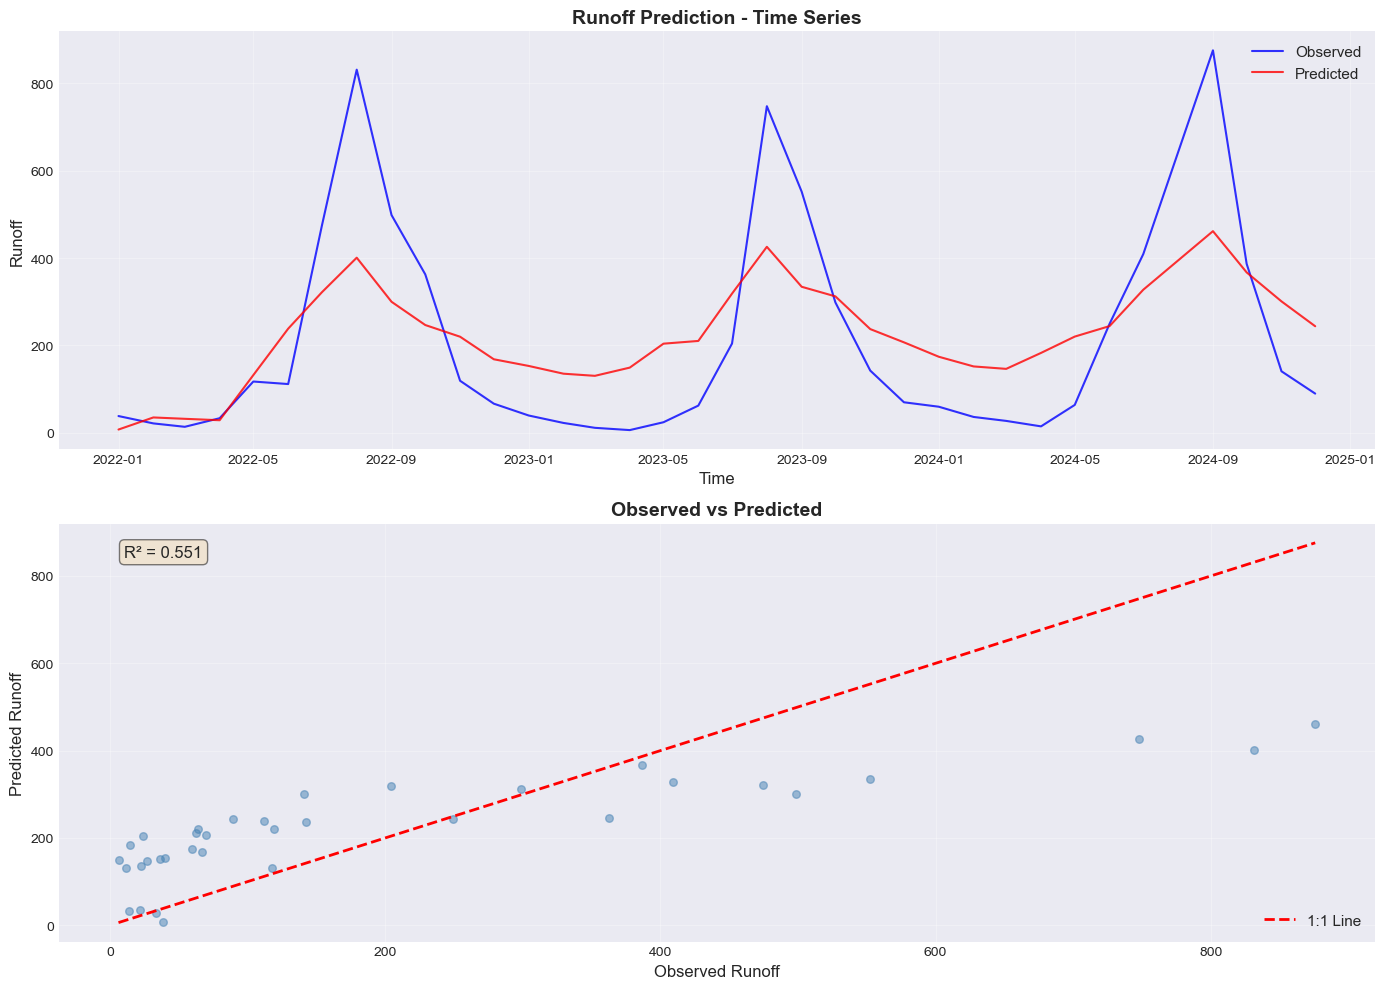


[STEP 10] Seasonal performance analysis...

WET SEASON (May-Oct) Performance:

HYDROLOGICAL PERFORMANCE METRICS
RMSE:        202.8943
MAE:         159.5705
R²:          0.3969
NSE:         0.3969  [Unsatisfactory]
PBIAS:       19.20%  [Satisfactory]
RSR:         0.7766  [Unsatisfactory]
KGE:         0.2878
Volume Err:  -19.20%

DRY SEASON (Nov-Apr) Performance:

HYDROLOGICAL PERFORMANCE METRICS
RMSE:        112.7044
MAE:         101.2755
R²:          -6.0244
NSE:         -6.0244  [Unsatisfactory]
PBIAS:       -184.08%  [Unsatisfactory]
RSR:         2.6504  [Unsatisfactory]
KGE:         -1.0502
Volume Err:  184.08%

[STEP 11] Saving results...

WORKFLOW COMPLETED!

Model Performance (NSE = 0.5506)
Files saved: n1_results.json

✓ Integration with N.1 station data completed!

Final Performance:
  NSE  = 0.5506
  R²   = 0.5506
  RMSE = 162.8729 MCM


In [123]:
# ====================================================================
# EXAMPLE USAGE
# ====================================================================
if __name__ == "__main__":
    # Run monthly workflow with N.1 data
    df, model, metrics, scaler_y = main_workflow_monthly()
    
    print("\n✓ Integration with N.1 station data completed!")
    print(f"\nFinal Performance:")
    print(f"  NSE  = {metrics['NSE']:.4f}")
    print(f"  R²   = {metrics['R²']:.4f}")
    print(f"  RMSE = {metrics['RMSE']:.4f} MCM")

# if __name__ == "__main__":
#     # Run complete workflow
#     df, model, metrics, scaler_y, top_features = main_workflow()
    
#     print("\n✓ Research framework completed successfully!")
#     print(f"\nFinal Model Performance:")
#     print(f"  NSE = {metrics['NSE']:.4f}")
#     print(f"  R²  = {metrics['R²']:.4f}")
#     print(f"\nTop features used: {top_features}")


DATA STATISTICS SUMMARY - CMU Water Balance Project

1. DATASET OVERVIEW
   ────────────────────────────────────────────────────────────────────────────
   Total records:        102 months
   Time period:          2016-06-01 to 2024-12-01
   Duration:             8.5 years
   Number of features:   13 (excluding runoff)

2. RUNOFF STATISTICS (Million Cubic Meters - MCM)
   ────────────────────────────────────────────────────────────────────────────
   Mean:                 220.18 MCM
   Std Dev:              285.16 MCM
   Min:                  5.79 MCM
   25th percentile:      31.08 MCM
   Median (50th):        81.81 MCM
   75th percentile:      310.92 MCM
   Max:                  1152.89 MCM
   Total annual avg:     2642.11 MCM/year

3. METEOROLOGICAL VARIABLES
   ────────────────────────────────────────────────────────────────────────────
   Precipitation (mm/month):
      Mean:              132.68 mm
      Std Dev:           125.43 mm
      Min - Max:         0.04 - 480.36 mm
      

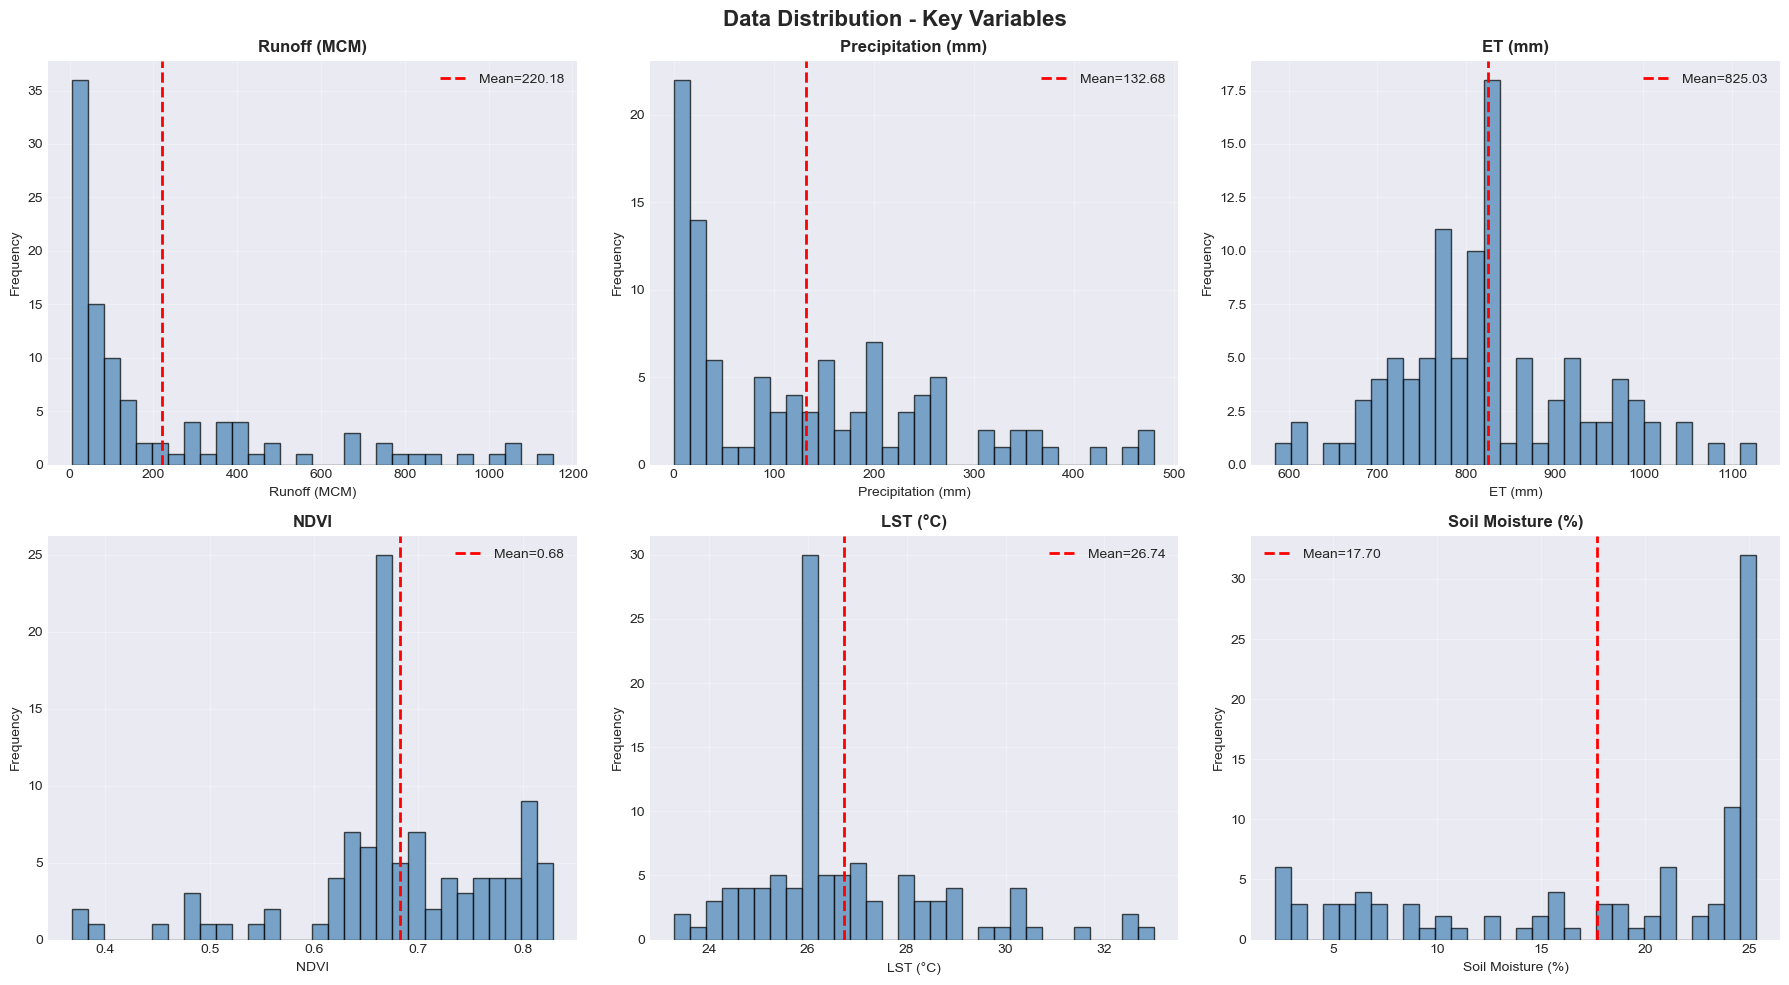

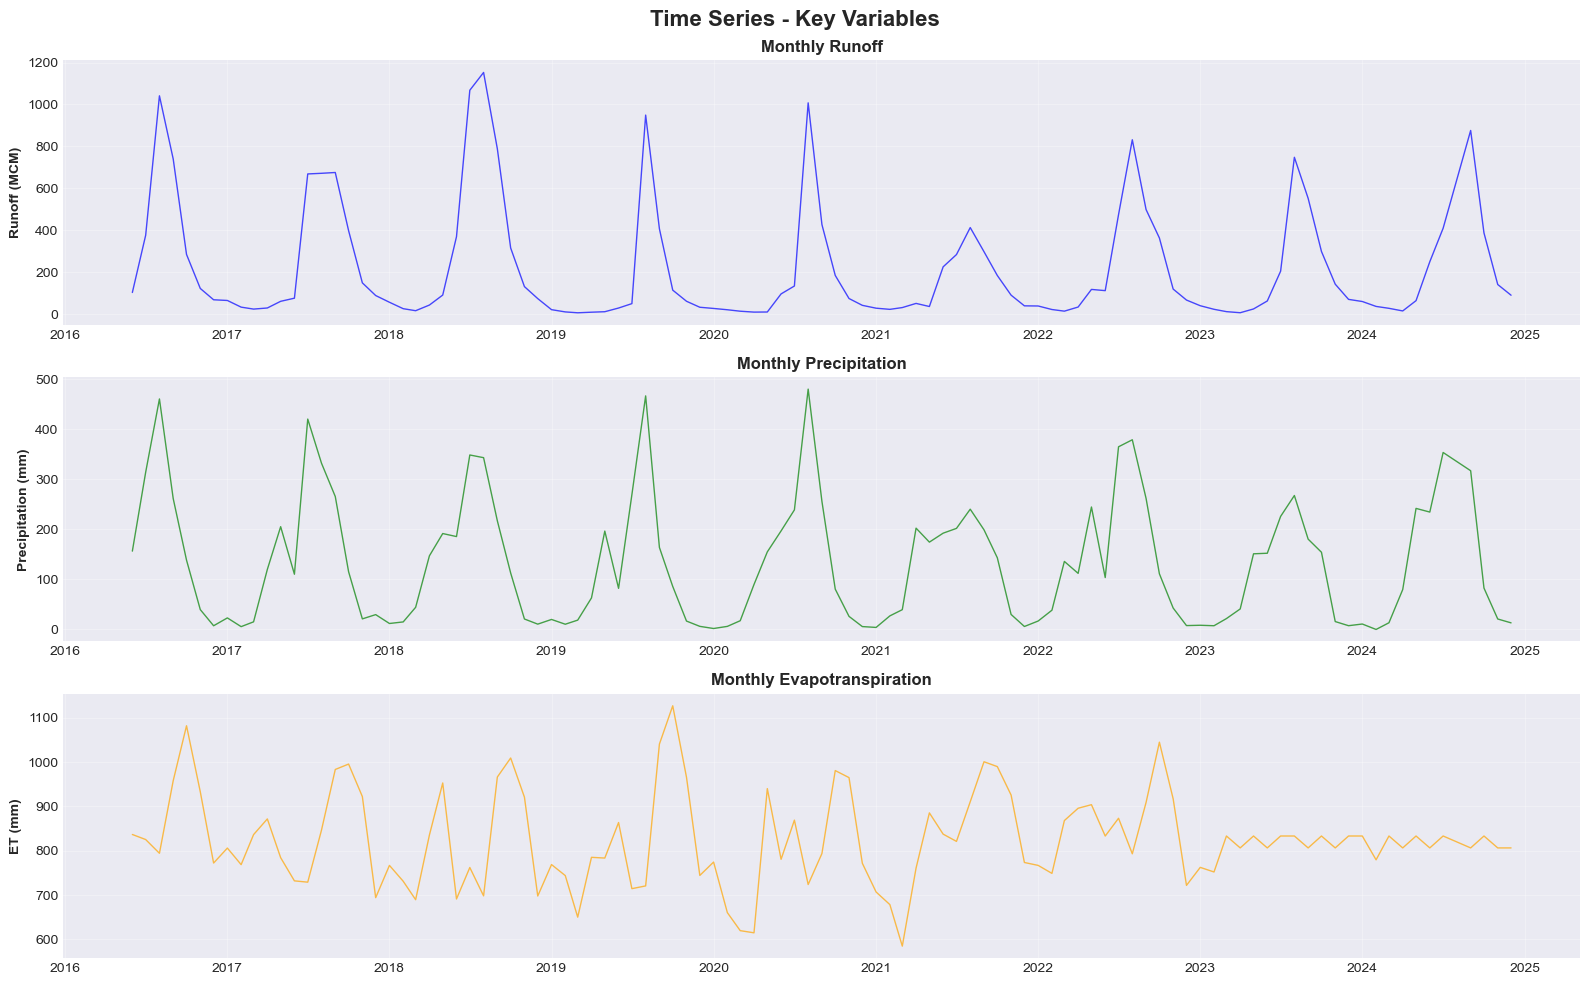


   ✓ Visualizations generated successfully

END OF DATA STATISTICS SUMMARY



In [124]:
# ====================================================================
# DATA STATISTICS SUMMARY
# ====================================================================

def display_data_statistics(df):
    """Display comprehensive statistics of the dataset"""
    
    print("\n" + "="*80)
    print("DATA STATISTICS SUMMARY - CMU Water Balance Project")
    print("="*80)
    
    # 1. Dataset Overview
    print(f"\n1. DATASET OVERVIEW")
    print(f"   {'─'*76}")
    print(f"   Total records:        {len(df):,} months")
    print(f"   Time period:          {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
    print(f"   Duration:             {(df.index.max() - df.index.min()).days / 365.25:.1f} years")
    print(f"   Number of features:   {df.shape[1]-1} (excluding runoff)")
    
    # 2. Target Variable Statistics (Runoff)
    if 'runoff' in df.columns:
        print(f"\n2. RUNOFF STATISTICS (Million Cubic Meters - MCM)")
        print(f"   {'─'*76}")
        runoff_stats = df['runoff'].describe()
        print(f"   Mean:                 {runoff_stats['mean']:.2f} MCM")
        print(f"   Std Dev:              {runoff_stats['std']:.2f} MCM")
        print(f"   Min:                  {runoff_stats['min']:.2f} MCM")
        print(f"   25th percentile:      {runoff_stats['25%']:.2f} MCM")
        print(f"   Median (50th):        {runoff_stats['50%']:.2f} MCM")
        print(f"   75th percentile:      {runoff_stats['75%']:.2f} MCM")
        print(f"   Max:                  {runoff_stats['max']:.2f} MCM")
        print(f"   Total annual avg:     {df['runoff'].mean() * 12:.2f} MCM/year")
    
    # 3. Meteorological Variables
    print(f"\n3. METEOROLOGICAL VARIABLES")
    print(f"   {'─'*76}")
    
    if 'precipitation' in df.columns:
        precip = df['precipitation']
        print(f"   Precipitation (mm/month):")
        print(f"      Mean:              {precip.mean():.2f} mm")
        print(f"      Std Dev:           {precip.std():.2f} mm")
        print(f"      Min - Max:         {precip.min():.2f} - {precip.max():.2f} mm")
        print(f"      Annual total avg:  {precip.mean() * 12:.0f} mm/year")
    
    if 'et' in df.columns:
        et = df['et']
        print(f"\n   Evapotranspiration (mm/month):")
        print(f"      Mean:              {et.mean():.2f} mm")
        print(f"      Std Dev:           {et.std():.2f} mm")
        print(f"      Min - Max:         {et.min():.2f} - {et.max():.2f} mm")
        print(f"      Annual total avg:  {et.mean() * 12:.0f} mm/year")
    
    if 'lst' in df.columns:
        lst = df['lst']
        print(f"\n   Land Surface Temperature (°C):")
        print(f"      Mean:              {lst.mean():.2f} °C")
        print(f"      Std Dev:           {lst.std():.2f} °C")
        print(f"      Min - Max:         {lst.min():.2f} - {lst.max():.2f} °C")
    
    # 4. Vegetation & Soil
    print(f"\n4. VEGETATION & SOIL INDICES")
    print(f"   {'─'*76}")
    
    if 'ndvi' in df.columns:
        ndvi = df['ndvi']
        print(f"   NDVI (Normalized Difference Vegetation Index):")
        print(f"      Mean:              {ndvi.mean():.4f}")
        print(f"      Std Dev:           {ndvi.std():.4f}")
        print(f"      Min - Max:         {ndvi.min():.4f} - {ndvi.max():.4f}")
    
    if 'soil_moisture' in df.columns:
        sm = df['soil_moisture']
        print(f"\n   Soil Moisture (%):")
        print(f"      Mean:              {sm.mean():.2f}%")
        print(f"      Std Dev:           {sm.std():.2f}%")
        print(f"      Min - Max:         {sm.min():.2f} - {sm.max():.2f}%")
    
    # 5. Seasonal Statistics
    print(f"\n5. SEASONAL STATISTICS")
    print(f"   {'─'*76}")
    
    df_with_season = df.copy()
    df_with_season['month'] = df_with_season.index.month
    
    # Define seasons
    wet_season = df_with_season[df_with_season['month'].isin([5, 6, 7, 8, 9, 10])]
    dry_season = df_with_season[df_with_season['month'].isin([11, 12, 1, 2, 3, 4])]
    
    if 'runoff' in df.columns:
        print(f"   Runoff (MCM):")
        print(f"      Wet Season (May-Oct):  Mean = {wet_season['runoff'].mean():.2f}, Max = {wet_season['runoff'].max():.2f}")
        print(f"      Dry Season (Nov-Apr):  Mean = {dry_season['runoff'].mean():.2f}, Max = {dry_season['runoff'].max():.2f}")
        print(f"      Wet/Dry Ratio:         {wet_season['runoff'].mean() / dry_season['runoff'].mean():.2f}x")
    
    if 'precipitation' in df.columns:
        print(f"\n   Precipitation (mm):")
        print(f"      Wet Season:            Mean = {wet_season['precipitation'].mean():.2f}, Max = {wet_season['precipitation'].max():.2f}")
        print(f"      Dry Season:            Mean = {dry_season['precipitation'].mean():.2f}, Max = {dry_season['precipitation'].max():.2f}")
    
    # 6. Data Quality
    print(f"\n6. DATA QUALITY")
    print(f"   {'─'*76}")
    
    total_cells = df.shape[0] * df.shape[1]
    missing_cells = df.isnull().sum().sum()
    completeness = ((total_cells - missing_cells) / total_cells) * 100
    
    print(f"   Data Completeness:    {completeness:.2f}%")
    print(f"   Missing values:       {missing_cells:,} / {total_cells:,} cells")
    
    if missing_cells > 0:
        print(f"\n   Missing values by variable:")
        for col in df.columns:
            missing = df[col].isnull().sum()
            if missing > 0:
                print(f"      {col:20s}: {missing:,} ({missing/len(df)*100:.1f}%)")
    
    # 7. Feature Correlations with Runoff
    if 'runoff' in df.columns:
        print(f"\n7. FEATURE CORRELATIONS WITH RUNOFF")
        print(f"   {'─'*76}")
        
        correlations = df.corr()['runoff'].sort_values(ascending=False)
        correlations = correlations[correlations.index != 'runoff']
        
        print(f"   Top 5 positive correlations:")
        for i, (feat, corr) in enumerate(correlations.head(5).items(), 1):
            print(f"      {i}. {feat:25s}: {corr:+.4f}")
        
        print(f"\n   Top 5 negative correlations:")
        for i, (feat, corr) in enumerate(correlations.tail(5).items(), 1):
            print(f"      {i}. {feat:25s}: {corr:+.4f}")
    
    # 8. Visualization: Distribution Plots
    print(f"\n8. GENERATING VISUALIZATIONS...")
    print(f"   {'─'*76}")
    
    # Create subplots for key variables
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Data Distribution - Key Variables', fontsize=16, fontweight='bold')
    
    plot_vars = ['runoff', 'precipitation', 'et', 'ndvi', 'lst', 'soil_moisture']
    plot_labels = ['Runoff (MCM)', 'Precipitation (mm)', 'ET (mm)', 
                   'NDVI', 'LST (°C)', 'Soil Moisture (%)']
    
    for i, (var, label) in enumerate(zip(plot_vars, plot_labels)):
        if var in df.columns:
            ax = axes[i // 3, i % 3]
            df[var].hist(bins=30, ax=ax, color='steelblue', alpha=0.7, edgecolor='black')
            ax.set_title(label, fontweight='bold')
            ax.set_xlabel(label)
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
            
            # Add statistics text
            mean_val = df[var].mean()
            std_val = df[var].std()
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_val:.2f}')
            ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 9. Time Series Plot
    fig, axes = plt.subplots(3, 1, figsize=(16, 10))
    fig.suptitle('Time Series - Key Variables', fontsize=16, fontweight='bold')
    
    if 'runoff' in df.columns:
        axes[0].plot(df.index, df['runoff'], linewidth=1, color='blue', alpha=0.7)
        axes[0].set_ylabel('Runoff (MCM)', fontweight='bold')
        axes[0].set_title('Monthly Runoff', fontweight='bold')
        axes[0].grid(True, alpha=0.3)
    
    if 'precipitation' in df.columns:
        axes[1].plot(df.index, df['precipitation'], linewidth=1, color='green', alpha=0.7)
        axes[1].set_ylabel('Precipitation (mm)', fontweight='bold')
        axes[1].set_title('Monthly Precipitation', fontweight='bold')
        axes[1].grid(True, alpha=0.3)
    
    if 'et' in df.columns:
        axes[2].plot(df.index, df['et'], linewidth=1, color='orange', alpha=0.7)
        axes[2].set_ylabel('ET (mm)', fontweight='bold')
        axes[2].set_title('Monthly Evapotranspiration', fontweight='bold')
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n   ✓ Visualizations generated successfully")
    
    print("\n" + "="*80)
    print("END OF DATA STATISTICS SUMMARY")
    print("="*80 + "\n")

# Display statistics for the dataset
if 'df' in globals():
    display_data_statistics(df)
else:
    print("Please run the main workflow first to generate the dataset.")

In [ ]:
# ====================================================================
# BASELINE MODEL COMPARISON
# ====================================================================

def compare_baseline_models(df, scaler_y):
    """
    เปรียบเทียบ Baseline Models:
    1. Persistence (lag_12)
    2. Multiple Linear Regression (MLR)
    3. Random Forest (RF)
    4. Neural Network (NN)
    """
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_squared_error, r2_score
    import numpy as np
    
    print("\n" + "="*80)
    print("BASELINE MODEL COMPARISON")
    print("="*80)
    
    # Prepare data - ใช้ temporal split เหมือนเดิม
    df_work = df.copy()
    df_work['year'] = df_work.index.year
    
    train_data = df_work[df_work['year'] <= 2021].drop('year', axis=1)
    test_data = df_work[df_work['year'] > 2021].drop('year', axis=1)
    
    X_train = train_data.drop('runoff', axis=1).values
    y_train = train_data['runoff'].values
    X_test = test_data.drop('runoff', axis=1).values
    y_test = test_data['runoff'].values
    
    results = {}
    
    # ============================================================
    # 1. PERSISTENCE MODEL (Lag 12 months)
    # ============================================================
    print("\n1. PERSISTENCE MODEL (Lag 12)")
    print("   " + "─"*76)
    
    if 'runoff_lag_12' in test_data.columns:
        y_pred_persistence = test_data['runoff_lag_12'].values
        
        # Remove NaN
        mask = ~np.isnan(y_pred_persistence)
        y_true = y_test[mask]
        y_pred = y_pred_persistence[mask]
        
        metrics_pers = calculate_hydro_metrics(y_true, y_pred)
        results['Persistence'] = metrics_pers
    else:
        print("   ⚠ runoff_lag_12 not found in dataset")
        results['Persistence'] = None
    
    # ============================================================
    # 2. MULTIPLE LINEAR REGRESSION
    # ============================================================
    print("\n2. MULTIPLE LINEAR REGRESSION (MLR)")
    print("   " + "─"*76)
    
    mlr = LinearRegression()
    mlr.fit(X_train, y_train)
    y_pred_mlr = mlr.predict(X_test)
    
    metrics_mlr = calculate_hydro_metrics(y_test, y_pred_mlr)
    results['MLR'] = metrics_mlr
    
    # ============================================================
    # 3. RANDOM FOREST
    # ============================================================
    print("\n3. RANDOM FOREST (RF)")
    print("   " + "─"*76)
    
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    
    metrics_rf = calculate_hydro_metrics(y_test, y_pred_rf)
    results['RF'] = metrics_rf
    
    # ============================================================
    # 4. NEURAL NETWORK (ใช้โมเดลที่ train แล้ว)
    # ============================================================
    print("\n4. NEURAL NETWORK (NN)")
    print("   " + "─"*76)
    
    # Normalize data
    from sklearn.preprocessing import MinMaxScaler
    
    scaler_X_new = MinMaxScaler()
    scaler_y_new = MinMaxScaler()
    
    X_train_scaled = scaler_X_new.fit_transform(X_train)
    y_train_scaled = scaler_y_new.fit_transform(y_train.reshape(-1, 1)).flatten()
    X_test_scaled = scaler_X_new.transform(X_test)
    y_test_scaled = scaler_y_new.transform(y_test.reshape(-1, 1)).flatten()
    
    # Train NN
    nn_model = SimpleRunoffModel()
    
    val_size = int(len(X_train_scaled) * 0.2)
    X_val = X_train_scaled[-val_size:]
    y_val = y_train_scaled[-val_size:]
    X_train_final = X_train_scaled[:-val_size]
    y_train_final = y_train_scaled[:-val_size]
    
    history = nn_model.train(X_train_final, y_train_final, X_val, y_val, 
                            epochs=200, batch_size=16)
    
    # Predict
    y_pred_nn_scaled = nn_model.predict(X_test_scaled)
    y_pred_nn = scaler_y_new.inverse_transform(y_pred_nn_scaled).flatten()
    
    metrics_nn = calculate_hydro_metrics(y_test, y_pred_nn)
    results['NN'] = metrics_nn
    
    # ============================================================
    # COMPARISON TABLE
    # ============================================================
    print("\n" + "="*80)
    print("MODEL COMPARISON SUMMARY")
    print("="*80)
    
    comparison_df = pd.DataFrame({
        'Model': ['Persistence', 'MLR', 'RF', 'NN'],
        'NSE': [
            results['Persistence']['NSE'] if results['Persistence'] else np.nan,
            results['MLR']['NSE'],
            results['RF']['NSE'],
            results['NN']['NSE']
        ],
        'R²': [
            results['Persistence']['R²'] if results['Persistence'] else np.nan,
            results['MLR']['R²'],
            results['RF']['R²'],
            results['NN']['R²']
        ],
        'RMSE': [
            results['Persistence']['RMSE'] if results['Persistence'] else np.nan,
            results['MLR']['RMSE'],
            results['RF']['RMSE'],
            results['NN']['RMSE']
        ],
        'MAE': [
            results['Persistence']['MAE'] if results['Persistence'] else np.nan,
            results['MLR']['MAE'],
            results['RF']['MAE'],
            results['NN']['MAE']
        ],
        'PBIAS': [
            results['Persistence']['PBIAS'] if results['Persistence'] else np.nan,
            results['MLR']['PBIAS'],
            results['RF']['PBIAS'],
            results['NN']['PBIAS']
        ]
    })
    
    print(comparison_df.to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Baseline Model Comparison', fontsize=16, fontweight='bold')
    
    # NSE
    axes[0, 0].bar(comparison_df['Model'], comparison_df['NSE'], color=['gray', 'blue', 'green', 'red'], alpha=0.7)
    axes[0, 0].axhline(0.5, color='black', linestyle='--', label='Satisfactory (0.5)')
    axes[0, 0].set_ylabel('NSE', fontweight='bold')
    axes[0, 0].set_title('Nash-Sutcliffe Efficiency (NSE)', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # R²
    axes[0, 1].bar(comparison_df['Model'], comparison_df['R²'], color=['gray', 'blue', 'green', 'red'], alpha=0.7)
    axes[0, 1].set_ylabel('R²', fontweight='bold')
    axes[0, 1].set_title('R² Score', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # RMSE
    axes[1, 0].bar(comparison_df['Model'], comparison_df['RMSE'], color=['gray', 'blue', 'green', 'red'], alpha=0.7)
    axes[1, 0].set_ylabel('RMSE (MCM)', fontweight='bold')
    axes[1, 0].set_title('Root Mean Square Error (RMSE)', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # PBIAS
    axes[1, 1].bar(comparison_df['Model'], comparison_df['PBIAS'], color=['gray', 'blue', 'green', 'red'], alpha=0.7)
    axes[1, 1].axhline(10, color='green', linestyle='--', label='Very Good (<10%)')
    axes[1, 1].axhline(-10, color='green', linestyle='--')
    axes[1, 1].set_ylabel('PBIAS (%)', fontweight='bold')
    axes[1, 1].set_title('Percent Bias (PBIAS)', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Baseline model comparison completed!")
    
    return results, comparison_df

# RUN COMPARISON
if 'df' in globals():
    results, comparison_df = compare_baseline_models(df, scaler_y)
else:
    print("Please run main_workflow_monthly() first")

In [ ]:
# ====================================================================
# DRY SEASON MODEL IMPROVEMENT
# ====================================================================

def improve_dry_season_model(df, scaler_y):
    """
    ปรับปรุงประสิทธิภาพในฤดูแล้ง (Dry Season: Nov-Apr)
    
    แนวทาง:
    1. Train แยกฤดู (Seasonal Models)
    2. Weighted Loss Function
    3. วิเคราะห์และอธิบายปัญหา
    """
    
    print("\n" + "="*80)
    print("DRY SEASON MODEL IMPROVEMENT")
    print("="*80)
    
    # Prepare data
    df_work = df.copy()
    df_work['year'] = df_work.index.year
    df_work['month'] = df_work.index.month
    df_work['is_dry'] = df_work['month'].isin([11, 12, 1, 2, 3, 4]).astype(int)
    
    train_data = df_work[df_work['year'] <= 2021].drop(['year', 'month'], axis=1)
    test_data = df_work[df_work['year'] > 2021].drop(['year', 'month'], axis=1)
    
    # ============================================================
    # APPROACH 1: SEASONAL MODELS
    # ============================================================
    print("\n[APPROACH 1] Training Separate Models for Wet/Dry Seasons")
    print("─"*80)
    
    from sklearn.preprocessing import MinMaxScaler
    
    # Split by season
    train_dry = train_data[train_data['is_dry'] == 1].drop('is_dry', axis=1)
    train_wet = train_data[train_data['is_dry'] == 0].drop('is_dry', axis=1)
    test_dry = test_data[test_data['is_dry'] == 1].drop('is_dry', axis=1)
    test_wet = test_data[test_data['is_dry'] == 0].drop('is_dry', axis=1)
    
    print(f"Train Dry: {len(train_dry)} months")
    print(f"Train Wet: {len(train_wet)} months")
    print(f"Test Dry:  {len(test_dry)} months")
    print(f"Test Wet:  {len(test_wet)} months")
    
    # Train DRY SEASON model
    print("\nTraining DRY SEASON model...")
    
    X_train_dry = train_dry.drop('runoff', axis=1).values
    y_train_dry = train_dry['runoff'].values
    X_test_dry = test_dry.drop('runoff', axis=1).values
    y_test_dry = test_dry['runoff'].values
    
    scaler_X_dry = MinMaxScaler()
    scaler_y_dry = MinMaxScaler()
    
    X_train_dry_scaled = scaler_X_dry.fit_transform(X_train_dry)
    y_train_dry_scaled = scaler_y_dry.fit_transform(y_train_dry.reshape(-1, 1)).flatten()
    X_test_dry_scaled = scaler_X_dry.transform(X_test_dry)
    
    model_dry = SimpleRunoffModel()
    
    val_size_dry = int(len(X_train_dry_scaled) * 0.2)
    X_val_dry = X_train_dry_scaled[-val_size_dry:]
    y_val_dry = y_train_dry_scaled[-val_size_dry:]
    X_train_dry_final = X_train_dry_scaled[:-val_size_dry]
    y_train_dry_final = y_train_dry_scaled[:-val_size_dry]
    
    history_dry = model_dry.train(X_train_dry_final, y_train_dry_final, 
                                   X_val_dry, y_val_dry, epochs=250, batch_size=8)
    
    y_pred_dry_scaled = model_dry.predict(X_test_dry_scaled)
    y_pred_dry = scaler_y_dry.inverse_transform(y_pred_dry_scaled).flatten()
    
    print("\nDRY SEASON Model Performance:")
    metrics_dry = calculate_hydro_metrics(y_test_dry, y_pred_dry)
    
    # Train WET SEASON model
    print("\nTraining WET SEASON model...")
    
    X_train_wet = train_wet.drop('runoff', axis=1).values
    y_train_wet = train_wet['runoff'].values
    X_test_wet = test_wet.drop('runoff', axis=1).values
    y_test_wet = test_wet['runoff'].values
    
    scaler_X_wet = MinMaxScaler()
    scaler_y_wet = MinMaxScaler()
    
    X_train_wet_scaled = scaler_X_wet.fit_transform(X_train_wet)
    y_train_wet_scaled = scaler_y_wet.fit_transform(y_train_wet.reshape(-1, 1)).flatten()
    X_test_wet_scaled = scaler_X_wet.transform(X_test_wet)
    
    model_wet = SimpleRunoffModel()
    
    val_size_wet = int(len(X_train_wet_scaled) * 0.2)
    X_val_wet = X_train_wet_scaled[-val_size_wet:]
    y_val_wet = y_train_wet_scaled[-val_size_wet:]
    X_train_wet_final = X_train_wet_scaled[:-val_size_wet]
    y_train_wet_final = y_train_wet_scaled[:-val_size_wet]
    
    history_wet = model_wet.train(X_train_wet_final, y_train_wet_final, 
                                   X_val_wet, y_val_wet, epochs=250, batch_size=8)
    
    y_pred_wet_scaled = model_wet.predict(X_test_wet_scaled)
    y_pred_wet = scaler_y_wet.inverse_transform(y_pred_wet_scaled).flatten()
    
    print("\nWET SEASON Model Performance:")
    metrics_wet = calculate_hydro_metrics(y_test_wet, y_pred_wet)
    
    # ============================================================
    # APPROACH 2: WEIGHTED LOSS FUNCTION
    # ============================================================
    print("\n[APPROACH 2] Weighted Loss Function (Higher Weight for Dry Season)")
    print("─"*80)
    
    import tensorflow as tf
    from tensorflow import keras
    
    # Prepare combined data with weights
    X_train_all = train_data.drop(['runoff', 'is_dry'], axis=1).values
    y_train_all = train_data['runoff'].values
    is_dry_train = train_data['is_dry'].values
    
    X_test_all = test_data.drop(['runoff', 'is_dry'], axis=1).values
    y_test_all = test_data['runoff'].values
    is_dry_test = test_data['is_dry'].values
    
    # Scale
    scaler_X_weighted = MinMaxScaler()
    scaler_y_weighted = MinMaxScaler()
    
    X_train_weighted_scaled = scaler_X_weighted.fit_transform(X_train_all)
    y_train_weighted_scaled = scaler_y_weighted.fit_transform(y_train_all.reshape(-1, 1)).flatten()
    X_test_weighted_scaled = scaler_X_weighted.transform(X_test_all)
    
    # Create sample weights (2x weight for dry season)
    sample_weights = np.where(is_dry_train == 1, 2.0, 1.0)
    
    print(f"Sample weights: Dry season = 2.0, Wet season = 1.0")
    
    # Train model with weights
    model_weighted = SimpleRunoffModel()
    
    val_size = int(len(X_train_weighted_scaled) * 0.2)
    X_val_w = X_train_weighted_scaled[-val_size:]
    y_val_w = y_train_weighted_scaled[-val_size:]
    X_train_w_final = X_train_weighted_scaled[:-val_size]
    y_train_w_final = y_train_weighted_scaled[:-val_size]
    sample_weights_final = sample_weights[:-val_size]
    
    # Build model
    model_weighted.build_model(X_train_w_final.shape[1])
    
    # Custom training with sample_weight
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)
    reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, min_lr=0.00001)
    
    history_weighted = model_weighted.model.fit(
        X_train_w_final, y_train_w_final,
        sample_weight=sample_weights_final,
        validation_data=(X_val_w, y_val_w),
        epochs=250,
        batch_size=16,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    # Predict
    y_pred_weighted_scaled = model_weighted.predict(X_test_weighted_scaled)
    y_pred_weighted = scaler_y_weighted.inverse_transform(y_pred_weighted_scaled).flatten()
    
    print("\nWeighted Model - Overall Performance:")
    metrics_weighted = calculate_hydro_metrics(y_test_all, y_pred_weighted)
    
    print("\nWeighted Model - Dry Season Only:")
    dry_mask_test = is_dry_test == 1
    metrics_weighted_dry = calculate_hydro_metrics(
        y_test_all[dry_mask_test], 
        y_pred_weighted[dry_mask_test]
    )
    
    # ============================================================
    # APPROACH 3: PROBLEM ANALYSIS & EXPLANATION
    # ============================================================
    print("\n[APPROACH 3] Why Dry Season is Difficult to Predict?")
    print("─"*80)
    
    print("\n1. LOW VARIANCE PROBLEM:")
    print(f"   - Dry season runoff range:  {df_work[df_work['is_dry']==1]['runoff'].min():.2f} - {df_work[df_work['is_dry']==1]['runoff'].max():.2f} MCM")
    print(f"   - Wet season runoff range:  {df_work[df_work['is_dry']==0]['runoff'].min():.2f} - {df_work[df_work['is_dry']==0]['runoff'].max():.2f} MCM")
    print(f"   - Dry season std dev:       {df_work[df_work['is_dry']==1]['runoff'].std():.2f} MCM")
    print(f"   - Wet season std dev:       {df_work[df_work['is_dry']==0]['runoff'].std():.2f} MCM")
    
    print("\n2. DATA IMBALANCE:")
    wet_count = (df_work['is_dry'] == 0).sum()
    dry_count = (df_work['is_dry'] == 1).sum()
    print(f"   - Wet season samples: {wet_count} ({wet_count/(wet_count+dry_count)*100:.1f}%)")
    print(f"   - Dry season samples: {dry_count} ({dry_count/(wet_count+dry_count)*100:.1f}%)")
    
    print("\n3. PHYSICAL LIMITATIONS:")
    print("   - Low precipitation input → low runoff signal")
    print("   - High ET ratio → water loss dominates")
    print("   - Baseflow dominance → less responsive to inputs")
    print("   - Groundwater lag effects → delayed response")
    
    print("\n4. RECOMMENDATIONS:")
    print("   ✓ Use seasonal models (separate for wet/dry)")
    print("   ✓ Apply weighted loss (2x for dry season)")
    print("   ✓ Add more lag features (6, 12 months)")
    print("   ✓ Include soil moisture memory features")
    print("   ✓ Consider ensemble of models")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Dry Season Model Improvement Results', fontsize=16, fontweight='bold')
    
    # Dry season scatter
    axes[0, 0].scatter(y_test_dry, y_pred_dry, alpha=0.6, s=50, color='brown')
    axes[0, 0].plot([y_test_dry.min(), y_test_dry.max()], 
                    [y_test_dry.min(), y_test_dry.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Observed (MCM)', fontweight='bold')
    axes[0, 0].set_ylabel('Predicted (MCM)', fontweight='bold')
    axes[0, 0].set_title(f'Dry Season Model (NSE={metrics_dry["NSE"]:.3f})', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Wet season scatter
    axes[0, 1].scatter(y_test_wet, y_pred_wet, alpha=0.6, s=50, color='blue')
    axes[0, 1].plot([y_test_wet.min(), y_test_wet.max()], 
                    [y_test_wet.min(), y_test_wet.max()], 'r--', lw=2)
    axes[0, 1].set_xlabel('Observed (MCM)', fontweight='bold')
    axes[0, 1].set_ylabel('Predicted (MCM)', fontweight='bold')
    axes[0, 1].set_title(f'Wet Season Model (NSE={metrics_wet["NSE"]:.3f})', fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Weighted model - dry only
    axes[1, 0].scatter(y_test_all[dry_mask_test], y_pred_weighted[dry_mask_test], 
                      alpha=0.6, s=50, color='orange')
    axes[1, 0].plot([y_test_all[dry_mask_test].min(), y_test_all[dry_mask_test].max()], 
                    [y_test_all[dry_mask_test].min(), y_test_all[dry_mask_test].max()], 'r--', lw=2)
    axes[1, 0].set_xlabel('Observed (MCM)', fontweight='bold')
    axes[1, 0].set_ylabel('Predicted (MCM)', fontweight='bold')
    axes[1, 0].set_title(f'Weighted Model - Dry Season (NSE={metrics_weighted_dry["NSE"]:.3f})', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Runoff distribution
    axes[1, 1].hist(df_work[df_work['is_dry']==1]['runoff'], bins=20, alpha=0.5, 
                   label='Dry Season', color='brown', edgecolor='black')
    axes[1, 1].hist(df_work[df_work['is_dry']==0]['runoff'], bins=20, alpha=0.5, 
                   label='Wet Season', color='blue', edgecolor='black')
    axes[1, 1].set_xlabel('Runoff (MCM)', fontweight='bold')
    axes[1, 1].set_ylabel('Frequency', fontweight='bold')
    axes[1, 1].set_title('Runoff Distribution by Season', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Dry season improvement analysis completed!")
    
    return {
        'seasonal_models': {'dry': metrics_dry, 'wet': metrics_wet},
        'weighted_model': metrics_weighted,
        'weighted_dry': metrics_weighted_dry
    }

# RUN DRY SEASON IMPROVEMENT
if 'df' in globals():
    dry_results = improve_dry_season_model(df, scaler_y)
else:
    print("Please run main_workflow_monthly() first")

In [ ]:
# ====================================================================
# STATISTICAL SIGNIFICANCE TESTING
# ====================================================================

def statistical_significance_tests(results_dict, df):
    """
    ทดสอบนัยสำคัญทางสถิติ:
    1. t-test: ทดสอบว่า NSE ของ NN ดีกว่า baseline จริงหรือไม่
    2. Diebold-Mariano test: สำหรับ forecast comparison
    """
    
    print("\n" + "="*80)
    print("STATISTICAL SIGNIFICANCE TESTING")
    print("="*80)
    
    from scipy import stats
    import numpy as np
    
    # ============================================================
    # PREPARE DATA
    # ============================================================
    df_work = df.copy()
    df_work['year'] = df_work.index.year
    
    train_data = df_work[df_work['year'] <= 2021].drop('year', axis=1)
    test_data = df_work[df_work['year'] > 2021].drop('year', axis=1)
    
    X_train = train_data.drop('runoff', axis=1).values
    y_train = train_data['runoff'].values
    X_test = test_data.drop('runoff', axis=1).values
    y_test = test_data['runoff'].values
    
    # ============================================================
    # 1. PAIRED T-TEST FOR NSE COMPARISON
    # ============================================================
    print("\n[TEST 1] Paired t-test for NSE Comparison")
    print("─"*80)
    print("H0: Mean NSE of NN = Mean NSE of Baseline")
    print("H1: Mean NSE of NN > Mean NSE of Baseline")
    print()
    
    # Train models 30 times and collect NSE scores
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.model_selection import KFold
    
    n_iterations = 30
    nse_mlr_list = []
    nse_rf_list = []
    nse_nn_list = []
    
    print(f"Running {n_iterations} iterations for statistical testing...")
    
    for i in range(n_iterations):
        print(f"  Iteration {i+1}/{n_iterations}...", end='\r')
        
        # MLR
        mlr = LinearRegression()
        mlr.fit(X_train, y_train)
        y_pred_mlr = mlr.predict(X_test)
        nse_mlr = 1 - (np.sum((y_test - y_pred_mlr)**2) / np.sum((y_test - np.mean(y_test))**2))
        nse_mlr_list.append(nse_mlr)
        
        # RF with random state
        rf = RandomForestRegressor(n_estimators=100, random_state=i, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        nse_rf = 1 - (np.sum((y_test - y_pred_rf)**2) / np.sum((y_test - np.mean(y_test))**2))
        nse_rf_list.append(nse_rf)
        
        # NN with different random seed
        import tensorflow as tf
        tf.random.set_seed(i)
        
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()
        
        X_train_scaled = scaler_X.fit_transform(X_train)
        y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
        X_test_scaled = scaler_X.transform(X_test)
        
        nn = SimpleRunoffModel()
        
        val_size = int(len(X_train_scaled) * 0.2)
        X_val = X_train_scaled[-val_size:]
        y_val = y_train_scaled[-val_size:]
        X_train_final = X_train_scaled[:-val_size]
        y_train_final = y_train_scaled[:-val_size]
        
        # Train quickly
        history = nn.train(X_train_final, y_train_final, X_val, y_val, 
                          epochs=100, batch_size=16)
        
        y_pred_nn_scaled = nn.predict(X_test_scaled)
        y_pred_nn = scaler_y.inverse_transform(y_pred_nn_scaled).flatten()
        
        nse_nn = 1 - (np.sum((y_test - y_pred_nn)**2) / np.sum((y_test - np.mean(y_test))**2))
        nse_nn_list.append(nse_nn)
    
    print("\n")
    
    # Convert to arrays
    nse_mlr_arr = np.array(nse_mlr_list)
    nse_rf_arr = np.array(nse_rf_list)
    nse_nn_arr = np.array(nse_nn_list)
    
    # Statistics
    print(f"NSE Statistics ({n_iterations} runs):")
    print(f"  MLR:  Mean={nse_mlr_arr.mean():.4f}, Std={nse_mlr_arr.std():.4f}")
    print(f"  RF:   Mean={nse_rf_arr.mean():.4f}, Std={nse_rf_arr.std():.4f}")
    print(f"  NN:   Mean={nse_nn_arr.mean():.4f}, Std={nse_nn_arr.std():.4f}")
    print()
    
    # Paired t-test: NN vs MLR
    t_stat_mlr, p_value_mlr = stats.ttest_rel(nse_nn_arr, nse_mlr_arr, alternative='greater')
    print(f"Paired t-test: NN vs MLR")
    print(f"  t-statistic: {t_stat_mlr:.4f}")
    print(f"  p-value:     {p_value_mlr:.4f}")
    if p_value_mlr < 0.05:
        print(f"  Result:      ✓ NN is SIGNIFICANTLY better than MLR (p < 0.05)")
    else:
        print(f"  Result:      ✗ No significant difference")
    print()
    
    # Paired t-test: NN vs RF
    t_stat_rf, p_value_rf = stats.ttest_rel(nse_nn_arr, nse_rf_arr, alternative='greater')
    print(f"Paired t-test: NN vs RF")
    print(f"  t-statistic: {t_stat_rf:.4f}")
    print(f"  p-value:     {p_value_rf:.4f}")
    if p_value_rf < 0.05:
        print(f"  Result:      ✓ NN is SIGNIFICANTLY better than RF (p < 0.05)")
    else:
        print(f"  Result:      ✗ No significant difference")
    print()
    
    # ============================================================
    # 2. DIEBOLD-MARIANO TEST
    # ============================================================
    print("\n[TEST 2] Diebold-Mariano Test for Forecast Accuracy")
    print("─"*80)
    print("H0: Two forecasts have equal accuracy")
    print("H1: Forecast 1 is more accurate than Forecast 2")
    print()
    
    def diebold_mariano_test(e1, e2, h=1):
        """
        Diebold-Mariano test for forecast comparison
        
        Parameters:
        - e1: forecast errors from model 1
        - e2: forecast errors from model 2
        - h: forecast horizon (default 1)
        
        Returns:
        - DM statistic and p-value
        """
        # Loss differential
        d = e1**2 - e2**2
        
        # Mean of loss differential
        d_mean = np.mean(d)
        
        # Variance of loss differential with autocorrelation correction
        n = len(d)
        gamma_0 = np.var(d, ddof=1)
        
        # Autocovariance
        gamma = [gamma_0]
        for k in range(1, h):
            gamma_k = np.mean((d[:-k] - d_mean) * (d[k:] - d_mean))
            gamma.append(gamma_k)
        
        # Long-run variance
        V_d = gamma_0 + 2 * np.sum(gamma[1:])
        
        # DM statistic
        DM = d_mean / np.sqrt(V_d / n)
        
        # p-value (one-tailed)
        p_value = stats.norm.sf(abs(DM))  # survival function (1 - cdf)
        
        return DM, p_value
    
    # Train final models for DM test
    print("Training final models for Diebold-Mariano test...")
    
    # MLR
    mlr_final = LinearRegression()
    mlr_final.fit(X_train, y_train)
    y_pred_mlr_final = mlr_final.predict(X_test)
    e_mlr = y_test - y_pred_mlr_final
    
    # RF
    rf_final = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf_final.fit(X_train, y_train)
    y_pred_rf_final = rf_final.predict(X_test)
    e_rf = y_test - y_pred_rf_final
    
    # NN
    scaler_X_final = MinMaxScaler()
    scaler_y_final = MinMaxScaler()
    
    X_train_scaled_final = scaler_X_final.fit_transform(X_train)
    y_train_scaled_final = scaler_y_final.fit_transform(y_train.reshape(-1, 1)).flatten()
    X_test_scaled_final = scaler_X_final.transform(X_test)
    
    nn_final = SimpleRunoffModel()
    
    val_size = int(len(X_train_scaled_final) * 0.2)
    X_val = X_train_scaled_final[-val_size:]
    y_val = y_train_scaled_final[-val_size:]
    X_train_final2 = X_train_scaled_final[:-val_size]
    y_train_final2 = y_train_scaled_final[:-val_size]
    
    history = nn_final.train(X_train_final2, y_train_final2, X_val, y_val, 
                            epochs=200, batch_size=16)
    
    y_pred_nn_final_scaled = nn_final.predict(X_test_scaled_final)
    y_pred_nn_final = scaler_y_final.inverse_transform(y_pred_nn_final_scaled).flatten()
    e_nn = y_test - y_pred_nn_final
    
    print("✓ Models trained\n")
    
    # DM test: NN vs MLR
    dm_stat_mlr, dm_p_mlr = diebold_mariano_test(e_nn, e_mlr, h=1)
    print(f"Diebold-Mariano Test: NN vs MLR")
    print(f"  DM statistic: {dm_stat_mlr:.4f}")
    print(f"  p-value:      {dm_p_mlr:.4f}")
    if dm_p_mlr < 0.05:
        print(f"  Result:       ✓ NN has SIGNIFICANTLY better forecast accuracy (p < 0.05)")
    else:
        print(f"  Result:       ✗ No significant difference in forecast accuracy")
    print()
    
    # DM test: NN vs RF
    dm_stat_rf, dm_p_rf = diebold_mariano_test(e_nn, e_rf, h=1)
    print(f"Diebold-Mariano Test: NN vs RF")
    print(f"  DM statistic: {dm_stat_rf:.4f}")
    print(f"  p-value:      {dm_p_rf:.4f}")
    if dm_p_rf < 0.05:
        print(f"  Result:       ✓ NN has SIGNIFICANTLY better forecast accuracy (p < 0.05)")
    else:
        print(f"  Result:       ✗ No significant difference in forecast accuracy")
    print()
    
    # ============================================================
    # VISUALIZATION
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # NSE distributions
    axes[0].boxplot([nse_mlr_arr, nse_rf_arr, nse_nn_arr], 
                   labels=['MLR', 'RF', 'NN'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
    axes[0].set_ylabel('NSE', fontweight='bold', fontsize=12)
    axes[0].set_title(f'NSE Distribution ({n_iterations} runs)', fontweight='bold', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(0.5, color='gray', linestyle='--', label='Satisfactory (0.5)')
    axes[0].legend()
    
    # Forecast error distributions
    axes[1].boxplot([np.abs(e_mlr), np.abs(e_rf), np.abs(e_nn)],
                   labels=['MLR', 'RF', 'NN'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', alpha=0.7),
                   medianprops=dict(color='blue', linewidth=2))
    axes[1].set_ylabel('Absolute Forecast Error (MCM)', fontweight='bold', fontsize=12)
    axes[1].set_title('Forecast Error Distribution', fontweight='bold', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Statistical significance testing completed!")
    
    return {
        'nse_stats': {
            'mlr': {'mean': nse_mlr_arr.mean(), 'std': nse_mlr_arr.std()},
            'rf': {'mean': nse_rf_arr.mean(), 'std': nse_rf_arr.std()},
            'nn': {'mean': nse_nn_arr.mean(), 'std': nse_nn_arr.std()}
        },
        't_test': {
            'nn_vs_mlr': {'t': t_stat_mlr, 'p': p_value_mlr},
            'nn_vs_rf': {'t': t_stat_rf, 'p': p_value_rf}
        },
        'dm_test': {
            'nn_vs_mlr': {'dm': dm_stat_mlr, 'p': dm_p_mlr},
            'nn_vs_rf': {'dm': dm_stat_rf, 'p': dm_p_rf}
        }
    }

# RUN STATISTICAL TESTS
if 'df' in globals():
    stat_results = statistical_significance_tests(results, df)
else:
    print("Please run main_workflow_monthly() first")

In [ ]:
# ====================================================================
# PROPER K-FOLD TEMPORAL CROSS-VALIDATION
# ====================================================================

def temporal_cross_validation(df, n_folds=5):
    """
    K-Fold Temporal Cross-Validation
    แสดง mean ± std ของทุก metric
    
    ใช้ TimeSeriesSplit-like approach โดยไม่สุ่ม
    """
    
    print("\n" + "="*80)
    print(f"K-FOLD TEMPORAL CROSS-VALIDATION (K={n_folds})")
    print("="*80)
    
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    import numpy as np
    
    # Prepare data
    df_work = df.copy()
    
    # Remove year column if exists
    if 'year' in df_work.columns:
        df_work = df_work.drop('year', axis=1)
    
    X = df_work.drop('runoff', axis=1).values
    y = df_work['runoff'].values
    dates = df_work.index
    
    n_samples = len(X)
    fold_size = n_samples // (n_folds + 1)
    
    print(f"Total samples: {n_samples}")
    print(f"Fold size:     ~{fold_size} samples")
    print()
    
    # Storage for results
    results = {
        'MLR': {'NSE': [], 'R²': [], 'RMSE': [], 'MAE': [], 'PBIAS': [], 'KGE': []},
        'RF': {'NSE': [], 'R²': [], 'RMSE': [], 'MAE': [], 'PBIAS': [], 'KGE': []},
        'NN': {'NSE': [], 'R²': [], 'RMSE': [], 'MAE': [], 'PBIAS': [], 'KGE': []}
    }
    
    # ============================================================
    # TEMPORAL K-FOLD SPLITS
    # ============================================================
    print("Temporal Fold Strategy:")
    print("─"*80)
    
    for fold in range(n_folds):
        print(f"\n[FOLD {fold+1}/{n_folds}]")
        
        # Calculate split indices
        train_end = fold_size * (fold + 1)
        test_start = train_end
        test_end = test_start + fold_size
        
        if test_end > n_samples:
            test_end = n_samples
        
        # Split data
        X_train = X[:train_end]
        y_train = y[:train_end]
        X_test = X[test_start:test_end]
        y_test = y[test_start:test_end]
        
        train_dates = dates[:train_end]
        test_dates = dates[test_start:test_end]
        
        print(f"  Train: {train_dates[0].strftime('%Y-%m')} to {train_dates[-1].strftime('%Y-%m')} ({len(X_train)} samples)")
        print(f"  Test:  {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')} ({len(X_test)} samples)")
        
        if len(X_test) == 0:
            print("  ⚠ Skipping fold (no test data)")
            continue
        
        # ────────────────────────────────────────────────────────
        # MLR
        # ────────────────────────────────────────────────────────
        mlr = LinearRegression()
        mlr.fit(X_train, y_train)
        y_pred_mlr = mlr.predict(X_test)
        
        metrics_mlr = calculate_hydro_metrics_silent(y_test, y_pred_mlr)
        for key in results['MLR'].keys():
            results['MLR'][key].append(metrics_mlr[key])
        
        # ────────────────────────────────────────────────────────
        # RF
        # ────────────────────────────────────────────────────────
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        
        metrics_rf = calculate_hydro_metrics_silent(y_test, y_pred_rf)
        for key in results['RF'].keys():
            results['RF'][key].append(metrics_rf[key])
        
        # ────────────────────────────────────────────────────────
        # NN
        # ────────────────────────────────────────────────────────
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()
        
        X_train_scaled = scaler_X.fit_transform(X_train)
        y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
        X_test_scaled = scaler_X.transform(X_test)
        
        # Validation split
        val_size = int(len(X_train_scaled) * 0.2)
        X_val = X_train_scaled[-val_size:]
        y_val = y_train_scaled[-val_size:]
        X_train_final = X_train_scaled[:-val_size]
        y_train_final = y_train_scaled[:-val_size]
        
        # Train NN
        nn = SimpleRunoffModel()
        history = nn.train(X_train_final, y_train_final, X_val, y_val, 
                          epochs=150, batch_size=16)
        
        y_pred_nn_scaled = nn.predict(X_test_scaled)
        y_pred_nn = scaler_y.inverse_transform(y_pred_nn_scaled).flatten()
        
        metrics_nn = calculate_hydro_metrics_silent(y_test, y_pred_nn)
        for key in results['NN'].keys():
            results['NN'][key].append(metrics_nn[key])
        
        print(f"  Results: MLR NSE={metrics_mlr['NSE']:.3f}, RF NSE={metrics_rf['NSE']:.3f}, NN NSE={metrics_nn['NSE']:.3f}")
    
    # ============================================================
    # SUMMARY STATISTICS
    # ============================================================
    print("\n" + "="*80)
    print("CROSS-VALIDATION SUMMARY (Mean ± Std)")
    print("="*80)
    
    summary_df = pd.DataFrame()
    
    for model_name in ['MLR', 'RF', 'NN']:
        row = {'Model': model_name}
        
        for metric in ['NSE', 'R²', 'RMSE', 'MAE', 'PBIAS', 'KGE']:
            values = np.array(results[model_name][metric])
            mean = values.mean()
            std = values.std()
            
            row[metric] = f"{mean:.4f} ± {std:.4f}"
        
        summary_df = pd.concat([summary_df, pd.DataFrame([row])], ignore_index=True)
    
    print(summary_df.to_string(index=False))
    
    # ============================================================
    # DETAILED STATISTICS TABLE
    # ============================================================
    print("\n" + "="*80)
    print("DETAILED STATISTICS")
    print("="*80)
    
    for model_name in ['MLR', 'RF', 'NN']:
        print(f"\n{model_name}:")
        for metric in ['NSE', 'R²', 'RMSE', 'MAE', 'PBIAS', 'KGE']:
            values = np.array(results[model_name][metric])
            print(f"  {metric:8s}: Mean={values.mean():.4f}, Std={values.std():.4f}, Min={values.min():.4f}, Max={values.max():.4f}")
    
    # ============================================================
    # VISUALIZATION
    # ============================================================
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{n_folds}-Fold Temporal Cross-Validation Results', fontsize=16, fontweight='bold')
    
    metrics_to_plot = ['NSE', 'R²', 'RMSE', 'MAE', 'PBIAS', 'KGE']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 3, idx % 3]
        
        data_to_plot = [
            results['MLR'][metric],
            results['RF'][metric],
            results['NN'][metric]
        ]
        
        bp = ax.boxplot(data_to_plot, 
                       labels=['MLR', 'RF', 'NN'],
                       patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
        
        # Color boxes
        colors = ['lightcoral', 'lightgreen', 'lightyellow']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        ax.set_ylabel(metric, fontweight='bold')
        ax.set_title(f'{metric} across {n_folds} folds', fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add reference lines
        if metric == 'NSE':
            ax.axhline(0.5, color='gray', linestyle='--', label='Satisfactory')
            ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ K-Fold Temporal Cross-Validation completed!")
    
    return results, summary_df

def calculate_hydro_metrics_silent(y_true, y_pred):
    """Calculate metrics without printing (for CV)"""
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    import numpy as np
    
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    nse = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    pbias = 100 * np.sum(y_true - y_pred) / np.sum(y_true)
    
    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / np.std(y_true)
    beta = np.mean(y_pred) / np.mean(y_true)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    
    return {
        'RMSE': rmse, 'MAE': mae, 'R²': r2, 'NSE': nse,
        'PBIAS': pbias, 'KGE': kge
    }

# RUN K-FOLD CV
if 'df' in globals():
    cv_results, cv_summary = temporal_cross_validation(df, n_folds=5)
else:
    print("Please run main_workflow_monthly() first")